**Data analysis of loan defalt data**                                  


#  Predicting cell tower battery degradation or forecasting network backup-power costs.

***objectives***: The goal is to predict the remaining useful life (RUL) of a cell tower battery (in hours) or the daily diesel/battery operational cost (in ZAR).

In [6]:
#importng all the necessary libraries
!pip install category_encoders
from glob import glob
import pandas as pd
import seaborn as sns
import numpy as np
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted
import matplotlib.pyplot as plt

import plotly.express as px

:CODE TO GENERATE SIMULATED DATA BASED ON THE CURRENT STATISTICS

In [2]:

num_records = 1000
np.random.seed(42)

# --- 1. Generate mapped baseline data ---
data = {
    # High Cardinality: Cell tower identifier
    'Tower_ID': [f"TWR-{np.random.randint(1000, 9999)}" for _ in range(num_records)],

    # Continuous Variables: Grid Tariffs & Grid Load
    'Grid_Tariff_ZAR_kWh': np.random.uniform(2.50, 4.50, num_records), # Replaces Avg_Price_ZAR
    'Tower_Load_kWh': np.random.uniform(500, 2500, num_records),      # Replaces Data_Usage_TB

    # Target Variables (Choose one for your model)
    'Battery_Capacity_Pct': np.random.uniform(60.0, 100.0, num_records), # Replaces Consumer_Feedback

    # Low Cardinality: Categorical features
    'Battery_Type': np.random.choice(['Lithium-Ion', 'Lead-Acid'], num_records, p=[0.7, 0.3]),
    'Region_Code': np.random.choice(['ZA-GP', 'ZA-ZN', 'ZA-WC', 'ZA-EC'], num_records),
    'Load_Shedding_Stage': np.random.choice(['Stage 0', 'Stage 2', 'Stage 4', 'Stage 6'], num_records, p=[0.4, 0.3, 0.2, 0.1])
}

df = pd.DataFrame(data)

# --- 2. Inject Missing Values strategically ---

# High Cardinality (Tower_ID): 5% missing due to telemetry logging failures
mask_tower = np.random.rand(num_records) < 0.05
df.loc[mask_tower, 'Tower_ID'] = np.nan

# Low Cardinality (Battery_Type): Missing systematically
# e.g., Older Lead-Acid towers often miss asset tags
mask_battery = (df['Battery_Type'] == 'Lead-Acid') & (np.random.rand(num_records) < 0.25)
df.loc[mask_battery, 'Battery_Type'] = np.nan

# Continuous Variable (Battery_Capacity_Pct): 10% missing due to sensor downtime
mask_sensor = np.random.rand(num_records) < 0.10
df.loc[mask_sensor, 'Battery_Capacity_Pct'] = np.nan





In [27]:
df["Battery_Capacity_Pct"].astype(float)

,Battery_Capacity_Pct
0,71.299843
1,74.122016
2,95.763772
3,97.858261
4,95.702329
...,...
995,70.213455
996,64.234973
997,74.195907
998,76.526901


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Tower_ID              951 non-null    object 
 1   Grid_Tariff_ZAR_kWh   1000 non-null   float64
 2   Tower_Load_kWh        1000 non-null   float64
 3   Battery_Capacity_Pct  910 non-null    float64
 4   Battery_Type          929 non-null    object 
 5   Region_Code           1000 non-null   object 
 6   Load_Shedding_Stage   1000 non-null   object 
dtypes: float64(3), object(4)
memory usage: 54.8+ KB


In [4]:
df.head()

,Tower_ID,Grid_Tariff_ZAR_kWh,Tower_Load_kWh,Battery_Capacity_Pct,Battery_Type,Region_Code,Load_Shedding_Stage
0,TWR-8270,4.223571,763.457547,71.299843,Lithium-Ion,ZA-ZN,Stage 4
1,TWR-1860,4.392231,1951.959820,74.122016,Lithium-Ion,ZA-ZN,Stage 0
2,TWR-6390,3.246619,2135.570660,95.763772,Lithium-Ion,ZA-EC,Stage 0
3,TWR-6191,3.041489,927.022733,97.858261,Lithium-Ion,ZA-GP,Stage 0
4,TWR-6734,3.787999,1511.705386,95.702329,Lithium-Ion,ZA-ZN,Stage 2


# EXPLORTORY  DATA ANALYSIS

### *distribution and data quality and cleaning *

**categorical data**


Text(0, 0.5, 'Number of towers affected')

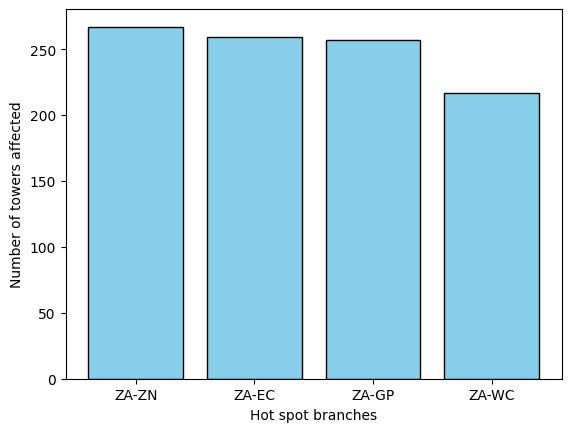

In [32]:
#the distribution of the catecories in each feature

plt.bar(df["Region_Code"].unique(), df["Region_Code"].value_counts(),
        color='skyblue',edgecolor='black')
plt.xlabel("Hot spot branches") # are provancies that are mostly affected by absence of network/wifi
plt.ylabel("Number of towers affected")

*as seen in the above the follwing provances according to the data have more towers they rely on which mean indireclty there is a large reliance on network or internet. whch further signals that  the kZN has the highest requirements which show that they might be the most affected costs in that region are expected to be increased

In [38]:
#Exploring the types of information found in the battery type
df["Battery_Type"].value_counts()# batterytype is a low cardinality feature  also needs to be removed

#exploring the infor given by the tower ID and it is most likely all of them are unique if not we may have a duplicate entry
#df["Tower_ID"].nunique() #which is 904  but is high cardinality feature needs to be removed

,count
Battery_Type,
Lithium-Ion,721
Lead-Acid,208


cleaening the data
imputing the missing values with the median
drop high and low caniality columns


In [43]:
##instead of dropping the data and loosing information , the impute the data with the median
df.drop(columns=["Battery_Type","Tower_ID"],inplace=True)
#battery capacity
battery_median = df["Battery_Capacity_Pct"].median()
df["Battery_Capacity_Pct"] = df["Battery_Capacity_Pct"].fillna(battery_median)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Grid_Tariff_ZAR_kWh   1000 non-null   float64
 1   Tower_Load_kWh        1000 non-null   float64
 2   Battery_Capacity_Pct  1000 non-null   float64
 3   Region_Code           1000 non-null   object 
 4   Load_Shedding_Stage   1000 non-null   object 
dtypes: float64(3), object(2)
memory usage: 39.2+ KB


this cell above shows our data is clean , in the almost symetrical distribution for all nummerical data.

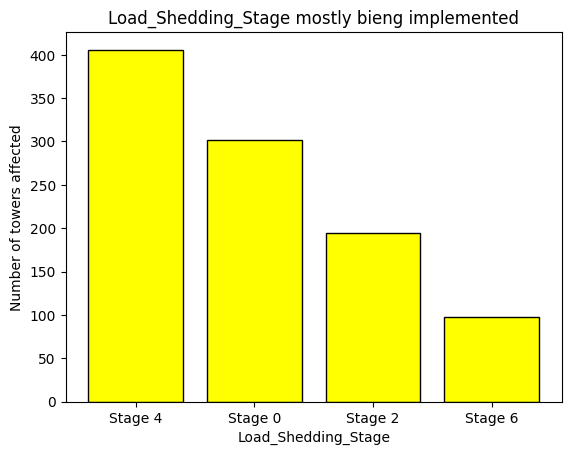

In [40]:
#the stages that affect the highlighted regions
plt.bar(df["Load_Shedding_Stage"].unique(), df["Load_Shedding_Stage"].value_counts(),
        color='yellow',edgecolor='black')
plt.xlabel("Load_Shedding_Stage") # are provancies that are mostly affected by absence of network/wifi
plt.ylabel("Number of towers affected")
plt.title("Load_Shedding_Stage mostly bieng implemented");


** from the data there less number of towers affected  when the  load shedding stages are stages 2 and 6 yet more of telecommunication  towers are affected

In [9]:
df.describe()

,Grid_Tariff_ZAR_kWh,Tower_Load_kWh,Battery_Capacity_Pct
count,1000.000000,1000.000000,910.000000
mean,3.504597,1495.308154,79.643047
std,0.587884,577.265758,11.408024
min,2.509880,500.269386,60.000465
25%,2.974750,1018.980123,69.875356
50%,3.527506,1496.068190,79.392653
75%,4.016489,1998.828529,89.540868
max,4.498827,2496.695023,99.982308


 avrage total cost of each grid is **R 3.504597 kwh** regardless of region and the loadshedding stage.the tower requirements are the **1495.308 kwh** on avarage  while  the battery capacity is **79.643047 kwh** .

 the more features we need is how many hrs the battery can last  as back up.

 the dostribution  among all the features are fairly towarsd symetrical with no significant difference between the mean of the data and the median.


each of the standard diviations and their respective means that there is a potential for outliers hence forth best paractice is to capp the top and bottom values in the data  ( not include the first 10% and values above the 90%).

to furher confirm outleirs is to use scatterplot for each of the above:
Grid_Tariff_ZAR_kWh,	Tower_Load_kWh	, Battery_Capacity_Pct

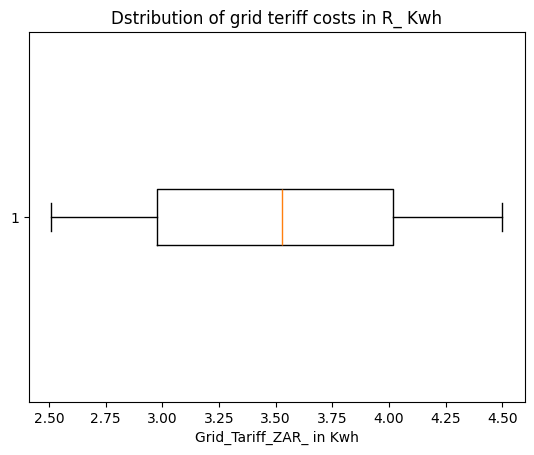

In [23]:
#distribution plots

plt.boxplot(df["Grid_Tariff_ZAR_kWh"],vert=False)
plt.xlabel("Grid_Tariff_ZAR_ in Kwh")
plt.title("Dstribution of grid teriff costs in R_ Kwh");

**the distribution of the data seems to be fairly symetrical and with that in mind even if the maximum and minimum  refer to the (summary statistics cell) valuses are  not within the standard dviation range +- looks good to work with.
the data showing  close to normal distribution, hence low variability of the data.why is this relevant it increases the confince or reliability  of forecasting or similar phenominon occaring again in furure , ofcouse if conditions remain the same.

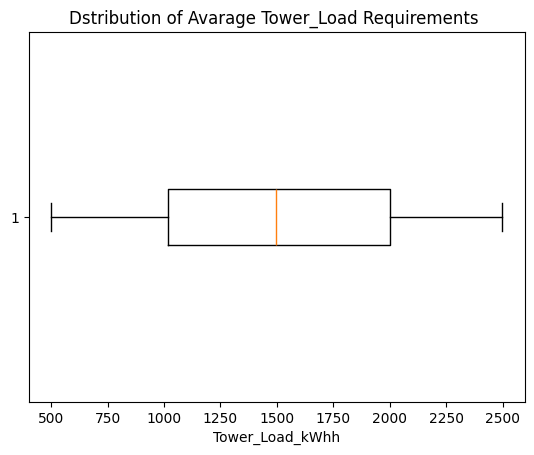

In [21]:
#distribution of tower requirements  on avarge
plt.boxplot(df["Tower_Load_kWh"],vert=False)
plt.xlabel("Tower_Load_kWhh")
plt.title("Dstribution of Avarage Tower_Load Requirements ");

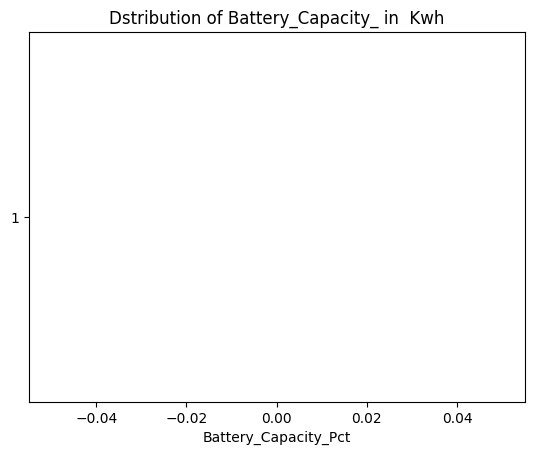

In [42]:
#distribution of avargae battery capacity whch kicks in when there is no supply of electricity to the tower which m
plt.boxplot(df["Battery_Capacity_Pct"],vert=False)
plt.xlabel("Battery_Capacity_Pct")
plt.title("Dstribution of Battery_Capacity_ in  Kwh");


Exploring the relationships between the features present and looking for any multicolinear features

In [46]:
#look at the corelation of the features aginst each other to see any strong signals
corr=df.select_dtypes(float).corr()
print(corr)

                      Grid_Tariff_ZAR_kWh  Tower_Load_kWh  \
Grid_Tariff_ZAR_kWh              1.000000        0.023156   
Tower_Load_kWh                   0.023156        1.000000   
Battery_Capacity_Pct            -0.004153       -0.011487   

                      Battery_Capacity_Pct  
Grid_Tariff_ZAR_kWh              -0.004153  
Tower_Load_kWh                   -0.011487  
Battery_Capacity_Pct              1.000000  


the relation ships between the features are very weak look at the